# Analysis of different models

- What features are important?
- Can we come up with a label for the output of each of our models?
- If I pair two users, can I express why in terms of my features?

### Setup

Goal is to recreate the data exactly as is, and then read in a model file

In [12]:
import os
import sys

# Get the absolute path of the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)


In [23]:
import pandas as pd
from pathlib import Path
import tensorflow as tf

from sklearn.preprocessing import StandardScaler

# from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP

import plotter as plotter


In [3]:
data_dir = Path("../../data/")

# read features
features_path = data_dir / "features_df.csv"
features_df = pd.read_csv(f"{features_path}")
print(f"Features Shape: {features_df.shape}")


Features Shape: (1932, 110)


In [4]:
# optionally read the edgelist in for now
edgelist_path = data_dir / "edgelists" / "edgelist_full.csv"
edgelist = pd.read_csv(f"{edgelist_path}")
print(f"Edgelist Shape: {edgelist.shape}")


Edgelist Shape: (3730692, 3)


In [6]:
# save user ids for mapping
user_ids = features_df["user_id"].values

# one-hot encode all categorical
cat_cols = features_df.select_dtypes(include=["object", "bool"]).columns.tolist()
if "user_id" in cat_cols:
    cat_cols.remove("user_id")
df_numeric = features_df.drop(columns=["user_id"])
df_numeric = pd.get_dummies(df_numeric, columns=cat_cols)
print("One-hot encoding complete")

# fillna with median
df_numeric = df_numeric.fillna(df_numeric.median())
print("Filled missing with median")

# standardize and construct the X matrix
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)
print(X.shape)

X_train, X_test, ids_train, ids_test = train_test_split(
    X, user_ids, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


One-hot encoding complete
Filled missing with median
(1932, 116)
Train Shape: (1545, 116), Test Shape: (387, 116)


/var/folders/jh/9_qy7nd96v9_q0_x1sffyq9c0000gn/T/ipykernel_52379/3140585386.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_df.select_dtypes(include=["object", "bool"]).columns.tolist()


### Config

test_meta: all the features for only the test users

all_meta: all the features for all the users

In [37]:
feature_lookup = features_df.set_index("user_id")
test_meta = feature_lookup.loc[ids_test].reset_index()
all_meta = feature_lookup.reset_index()


/var/folders/jh/9_qy7nd96v9_q0_x1sffyq9c0000gn/T/ipykernel_52379/2686144022.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_meta = feature_lookup.loc[ids_test].reset_index()
/var/folders/jh/9_qy7nd96v9_q0_x1sffyq9c0000gn/T/ipykernel_52379/2686144022.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_meta = feature_lookup.reset_index()


### Model

In [19]:
models_dir = Path("./experiments")
model_path = (
    "20260319_1018/model_enc32_dep1_lr0.0025_pat10_drop0.1_batch32_bn_act-linear.keras"
)
full_model = tf.keras.models.load_model(models_dir / model_path)


Note that this is the model object we trained. The model was generated by our custom 
class. To extract the encoder, we need this

In [22]:
bottleneck_output = full_model.get_layer("bottleneck_output").output
# wrap the encoder around the full_model.input and the bottleneck output layers.
encoder = tf.keras.Model(inputs=full_model.input, outputs=bottleneck_output)
all_embeddings = encoder.predict(X, verbose=0)

### Correlation between features and encoded outputs

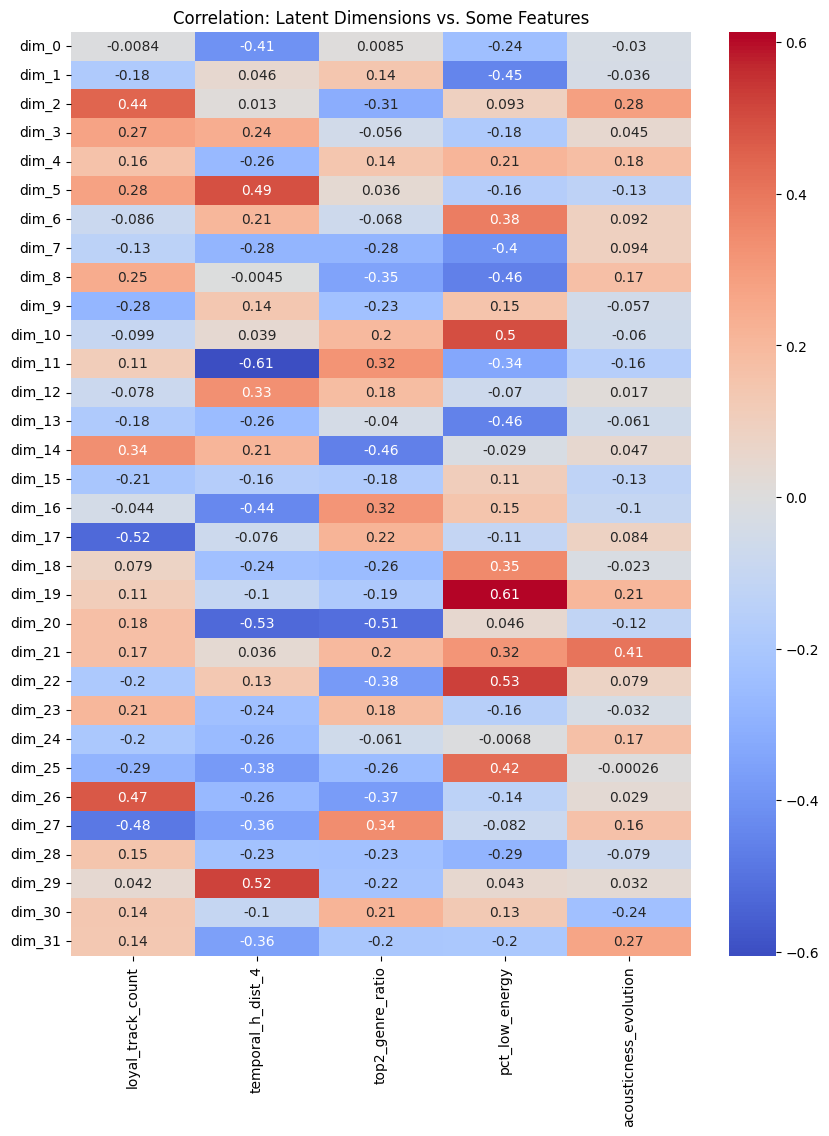

In [42]:
# Create a DataFrame of your 32 dimensions
latent_cols = [f"dim_{i}" for i in range(all_embeddings.shape[1])]
latent_df = pd.DataFrame(all_embeddings, columns=latent_cols)

# PICK SOME FEATURES HERE
some_features = [
    "loyal_track_count",
    "temporal_h_dist_4",
    "top2_genre_ratio",
    "pct_low_energy",
    "acousticness_evolution",
]
data = all_meta[some_features]

# Calculate correlation between the 32 dimensions and the artist features
corr_matrix = pd.concat([latent_df, data], axis=1).corr()
features_latent_corr = corr_matrix.loc[latent_cols, some_features]

# Plot heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(features_latent_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Latent Dimensions vs. Some Features")
plt.show()


### Is the model using the feature to group data?

UMAP takes our users from 32D and maps them to 2D, like PCA. However, it respects 
distance a lot more. We can play around with the n_neighbors and min_dist configs

In [43]:
# can configure
reducer = UMAP(n_neighbors=20, min_dist=0.25, random_state=42)
embedding_2d = reducer.fit_transform(all_embeddings)


/Users/sanch/workspace/spotify-app/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


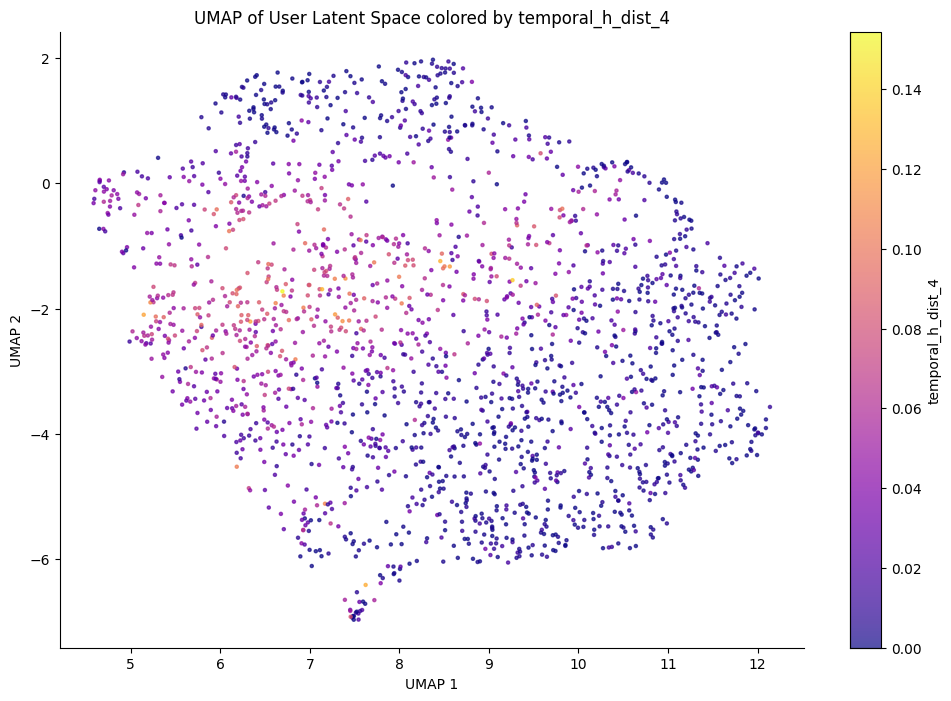

In [45]:
# PICK A RANDOM FEATURE
target_feature = "temporal_h_dist_4"
color_values = feature_lookup[target_feature]

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=color_values,
    cmap="plasma",  # magma, plasma, or viridis
    s=5,
    alpha=0.7,
)

plt.colorbar(scatter, label=target_feature)
plt.title(f"UMAP of User Latent Space colored by {target_feature}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
sns.despine()
plt.show()
